<a href="https://colab.research.google.com/github/Yousef-Shihade/information-retrieval-course-tasks/blob/main/Task_05_Query_Expansion/Query_Expansion_W2V.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Num of docs : 20

Example – original vs preprocessed:
Original : The UFC is the biggest mixed martial arts promotion in the world, hosting events in huge arenas.
Processed: ['ufc', 'biggest', 'mix', 'martial', 'art', 'promot', 'world', 'host', 'event', 'huge', 'arena']

 Similar words to 'fight' (stemmed) : 
[('bonus', 0.972183346748352),
 ('award', 0.9715467095375061),
 ('perform', 0.9660559892654419),
 ('titl', 0.9660071730613708),
 ('shot', 0.9616943597793579)]

 TF-IDF mtrx shape (docs × vocab)  : (20, 152)

 Example queries :  ['knockout finish', 'title fight', 'brazilian jiu jitsu']

QUERY: 'knockout finish'

 Tokens :  ['knockout', 'finish']
 Tokens (expanded) :  ['knockout', 'finish', 'power', 'balanc', 'lightweight']

 Top docs – ORIGINAL query :


,Rank,Doc ID,Similarity,Snippet
0,1,3,0.3587,Knockouts are very common in the lightweight a...
1,2,19,0.0000,Prospects in the sport usually start on prelim...
2,3,17,0.0000,"The UFC has events all over the world, from La..."
3,4,18,0.0000,MMA fans enjoy analyzing statistics like signi...
4,5,16,0.0000,Fight night bonuses are awarded for performanc...



 Top docs – EXPANDED query :


,Rank,Doc ID,Similarity,Snippet
0,1,3,0.7174,Knockouts are very common in the lightweight a...
1,2,19,0.0000,Prospects in the sport usually start on prelim...
2,3,17,0.0000,"The UFC has events all over the world, from La..."
3,4,18,0.0000,MMA fans enjoy analyzing statistics like signi...
4,5,16,0.0000,Fight night bonuses are awarded for performanc...


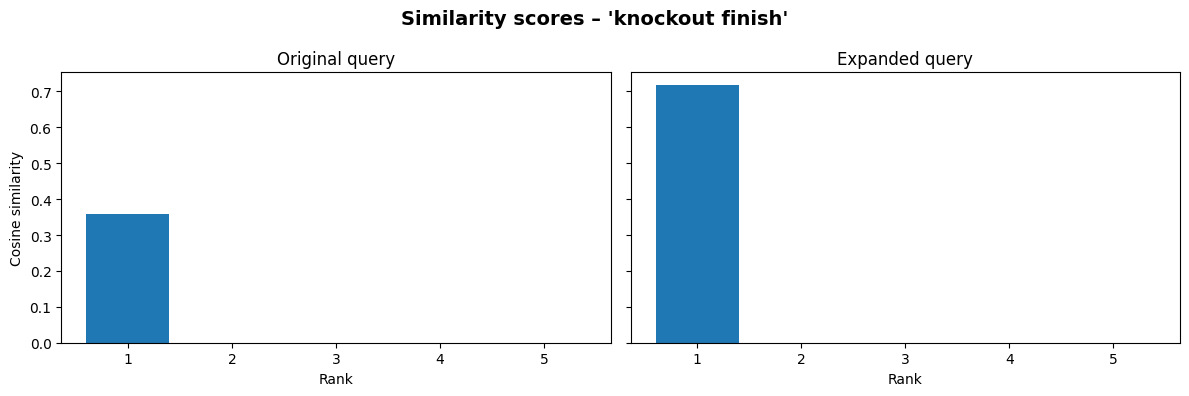


QUERY: 'title fight'

 Tokens :  ['titl', 'fight']
 Tokens (expanded) :  ['titl', 'fight', 'shot', 'pay', 'next', 'bonus', 'award', 'perform']

 Top docs – ORIGINAL query :


,Rank,Doc ID,Similarity,Snippet
0,1,4,0.3703,Title fights are scheduled for five rounds and...
1,2,14,0.3005,Pay per view events often include several rank...
2,3,16,0.1611,Fight night bonuses are awarded for performanc...
3,4,15,0.1084,Weight cutting before the fight is a controver...
4,5,5,0.1067,Wrestling is an important base in MMA because ...



 Top docs – EXPANDED query :


,Rank,Doc ID,Similarity,Snippet
0,1,14,0.4438,Pay per view events often include several rank...
1,2,16,0.3731,Fight night bonuses are awarded for performanc...
2,3,4,0.1444,Title fights are scheduled for five rounds and...
3,4,15,0.0423,Weight cutting before the fight is a controver...
4,5,5,0.0416,Wrestling is an important base in MMA because ...


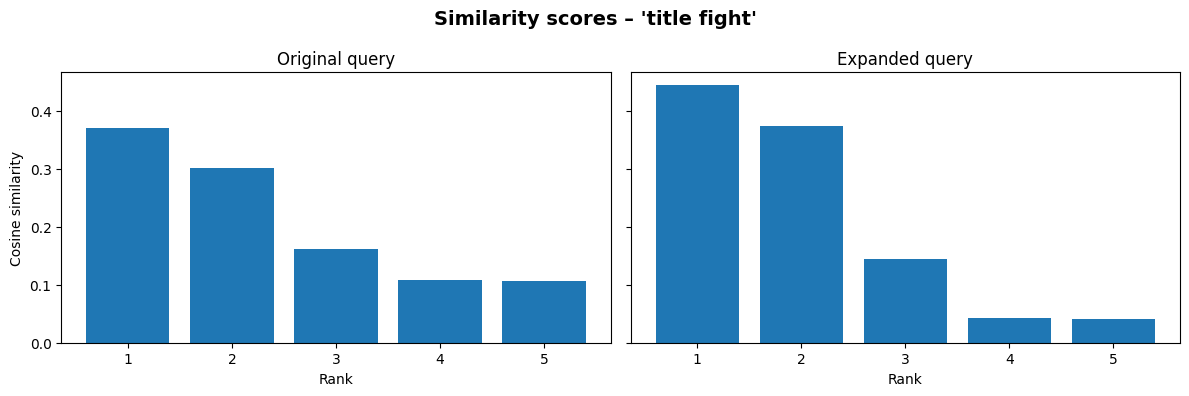


QUERY: 'brazilian jiu jitsu'

 Tokens :  ['brazilian', 'jiu', 'jitsu']
 Tokens (expanded) :  ['brazilian', 'jiu', 'jitsu', 'background', 'come', 'win', 'mani', 'becom', 'well']

 Top docs – ORIGINAL query :


,Rank,Doc ID,Similarity,Snippet
0,1,1,0.5246,Many fighters come from a background in Brazil...
1,2,10,0.2740,Many champions in the sport cross train in Mua...
2,3,19,0.0000,Prospects in the sport usually start on prelim...
3,4,18,0.0000,MMA fans enjoy analyzing statistics like signi...
4,5,16,0.0000,Fight night bonuses are awarded for performanc...



 Top docs – EXPANDED query :


,Rank,Doc ID,Similarity,Snippet
0,1,1,0.7204,Many fighters come from a background in Brazil...
1,2,10,0.4236,Many champions in the sport cross train in Mua...
2,3,19,0.0000,Prospects in the sport usually start on prelim...
3,4,18,0.0000,MMA fans enjoy analyzing statistics like signi...
4,5,16,0.0000,Fight night bonuses are awarded for performanc...


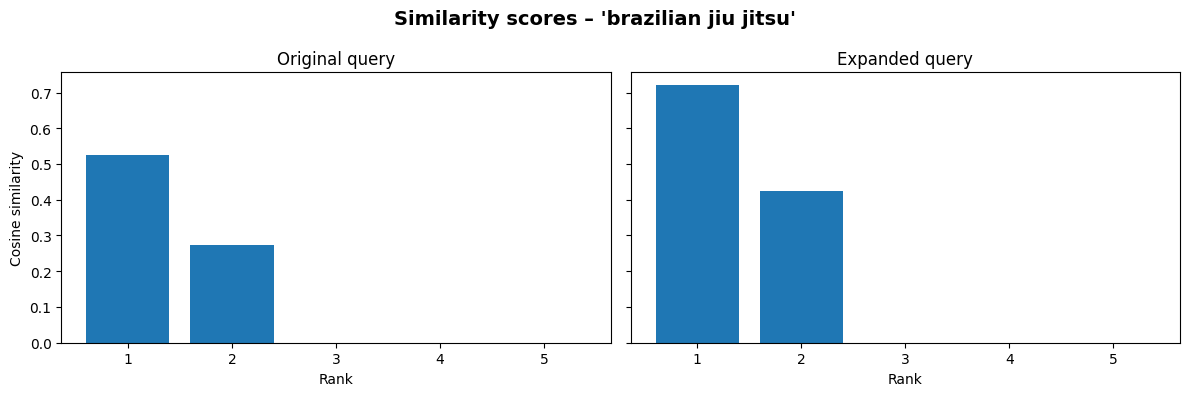


 Avg similarity of top-5 docs : 


,Query,AvgSim_Original,AvgSim_Expanded
0,knockout finish,0.07174,0.14348
1,title fight,0.20940,0.20904
2,brazilian jiu jitsu,0.15972,0.22880


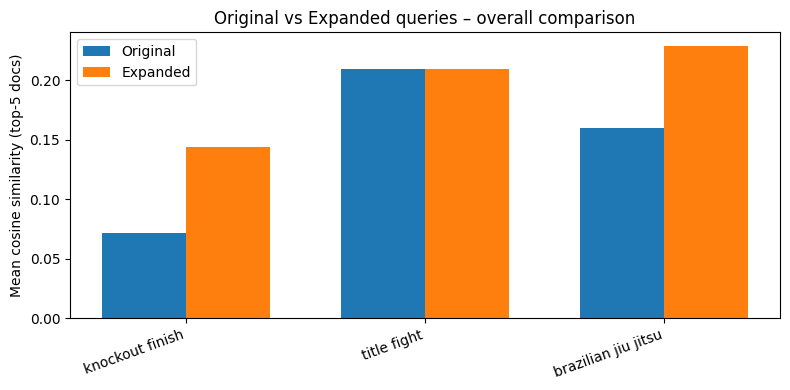

In [ ]:
# Task 05: Semantic Query Expansion using Word2Vec
# Yousef Shihade


# --Install libraries--
!pip -q install nltk gensim scikit-learn

import re
import numpy as np
from pprint import pprint

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# --  UFC / MMA corpus --
documents_raw = [
    "The UFC is the biggest mixed martial arts promotion in the world, hosting events in huge arenas.",
    "Many fighters come from a background in Brazilian jiu jitsu and use submissions to win their bouts.",
    "A typical MMA fight takes place inside the octagon and is contested over three or five rounds.",
    "Knockouts are very common in the lightweight and welterweight divisions where speed and power are balanced.",
    "Title fights are scheduled for five rounds and usually headline the main card of a UFC event.",
    "Wrestling is an important base in MMA because it allows fighters to control where the fight takes place.",
    "Strikers often use leg kicks, jabs, and head kicks to keep their opponents at distance.",
    "Ground and pound is a strategy where a fighter takes the opponent down and lands punches and elbows from the top.",
    "Judges score UFC fights using the ten point must system, focusing on effective striking and grappling.",
    "Fight camps last several weeks and include sparring, conditioning, and game planning for a specific opponent.",
    "Many champions in the sport cross train in Muay Thai, boxing, wrestling, and jiu jitsu to become well rounded.",
    "The featherweight division is known for its fast pace and technical striking exchanges.",
    "Some fighters prefer to pressure their opponents against the cage and look for takedowns from the clinch.",
    "Submissions such as the rear naked choke and armbar are high percentage techniques in MMA.",
    "Pay per view events often include several ranked contenders fighting for a chance at the next title shot.",
    "Weight cutting before the fight is a controversial topic because of the health risks to the athletes.",
    "Fight night bonuses are awarded for performance of the night and fight of the night.",
    "The UFC has events all over the world, from Las Vegas to Abu Dhabi and London.",
    "MMA fans enjoy analyzing statistics like significant strikes landed and takedown defense.",
    "Prospects in the sport usually start on preliminary cards before moving up to main card spots.",
]
print(f"Num of docs : {len(documents_raw)}")

# -- 2. Pre-processing --
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    cleaned = []
    for tok in tokens:
        if tok in stop_words:
            continue
        if len(tok) < 3:
            continue
        cleaned.append(stemmer.stem(tok))
    return cleaned

tokenized_docs = [preprocess_text(doc) for doc in documents_raw]

print("\nExample – original vs preprocessed:")
print("Original :", documents_raw[0])
print("Processed:", tokenized_docs[0])

# -- Train Word2Vec --
w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,           # skip-gram
    epochs=200,
)

stem_fight = stemmer.stem("fight")
if stem_fight in w2v_model.wv:
    print("\n Similar words to 'fight' (stemmed) : ")
    pprint(w2v_model.wv.most_similar(stem_fight, topn=5))

# -- 4. TF-IDF document matrix --
documents_clean = [' '.join(tokens) for tokens in tokenized_docs]
tfidf_vectorizer = TfidfVectorizer()
doc_tfidf = tfidf_vectorizer.fit_transform(documents_clean)
print("\n TF-IDF mtrx shape (docs × vocab)  :", doc_tfidf.shape)

# -- Helper funcs --
def preprocess_query_tokens(query: str):
    return preprocess_text(query)

def expand_query_with_w2v(query: str, model, topn: int = 3):
    tokens = preprocess_query_tokens(query)
    expanded_tokens = tokens.copy()
    for tok in tokens:
        if tok in model.wv:
            similar = [w for (w, score) in model.wv.most_similar(tok, topn=topn)]
            expanded_tokens.extend(similar)
    seen = set()
    unique_tokens = []
    for t in expanded_tokens:
        if t not in seen:
            unique_tokens.append(t)
            seen.add(t)
    return unique_tokens

def rank_documents(query_tokens, vectorizer, doc_matrix, top_k: int = 5):
    query_text_clean = ' '.join(query_tokens)
    q_vec = vectorizer.transform([query_text_clean])
    sims = cosine_similarity(q_vec, doc_matrix)[0]
    ranked_idx = np.argsort(sims)[::-1]
    results = [(int(idx), float(sims[idx])) for idx in ranked_idx[:top_k]]
    return results

def ranking_to_df(results, docs, label_prefix="Doc"):
    rows = []
    for rank, (idx, score) in enumerate(results, start=1):
        rows.append({
            "Rank": rank,
            "Doc ID": idx,
            "Similarity": round(score, 4),
            "Snippet": docs[idx][:90] + ("..." if len(docs[idx]) > 90 else "")
        })
    return pd.DataFrame(rows)

def plot_ranking(df_base, df_exp, query_text):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    fig.suptitle(f"Similarity scores – '{query_text}'", fontsize=14, fontweight="bold")

    axes[0].bar(df_base["Rank"], df_base["Similarity"])
    axes[0].set_title("Original query")
    axes[0].set_xlabel("Rank")
    axes[0].set_ylabel("Cosine similarity")
    axes[0].set_xticks(df_base["Rank"])

    axes[1].bar(df_exp["Rank"], df_exp["Similarity"])
    axes[1].set_title("Expanded query")
    axes[1].set_xlabel("Rank")
    axes[1].set_xticks(df_exp["Rank"])

    plt.tight_layout()
    plt.show()

# --  Example UFC / MMA queries --
example_queries = [
    "knockout finish",
    "title fight",
    "brazilian jiu jitsu",
]

print("\n Example queries : ", example_queries)

# -- Run retrieval and show tables & graphs --
all_summaries = []

for q in example_queries:
    print("\n" + "=" * 120)
    print(f"QUERY: '{q}'")

    q_tokens = preprocess_query_tokens(q)
    base_results = rank_documents(q_tokens, tfidf_vectorizer, doc_tfidf)
    df_base = ranking_to_df(base_results, documents_raw)

    expanded_tokens = expand_query_with_w2v(q, w2v_model, topn=3)
    expanded_results = rank_documents(expanded_tokens, tfidf_vectorizer, doc_tfidf)
    df_exp = ranking_to_df(expanded_results, documents_raw)

    print("\n Tokens : ", q_tokens)
    print(" Tokens (expanded) : ", expanded_tokens)

    print("\n Top docs – ORIGINAL query :")
    display(df_base)

    print("\n Top docs – EXPANDED query :")
    display(df_exp)

    # Plot similarity bar charts
    plot_ranking(df_base, df_exp, q)

    # Store average similarity summary for later global comparison
    all_summaries.append({
        "Query": q,
        "AvgSim_Original": df_base["Similarity"].mean(),
        "AvgSim_Expanded": df_exp["Similarity"].mean()
    })

# --  Summary comparison table --
summary_df = pd.DataFrame(all_summaries)
print("\n Avg similarity of top-5 docs : ")
display(summary_df)

# Global bar chart comparing mean similarity for each query
x = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, summary_df["AvgSim_Original"], width, label="Original")
ax.bar(x + width/2, summary_df["AvgSim_Expanded"], width, label="Expanded")


ax.set_xticks(x)
ax.set_xticklabels(summary_df["Query"], rotation=20, ha="right")
ax.set_ylabel("Mean cosine similarity (top-5 docs)")
ax.set_title("Original vs Expanded queries – overall comparison")
ax.legend()
plt.tight_layout()
plt.show()